# 07 · Recursive Multi-Step Forecasting

## tl;dr

本实验固定 06 的 HistGradientBoostingRegressor 与 47 个特征，从 **one-step** 转为在每个预测起点一次性递归预测未来 **168 小时**。06 风格 one-step MAE 为 **360.09**；60 个滚动起点的 recursive 168h 整段 MAE 为 **860.43**（RMSE **1290.69**），仍优于最强简单基线 Weekly Seasonal Naive 的 **1269.40**。递归 Day 1 → Day 7 MAE 为 **708.7 → 903.1**。未来天气在这里被当作已知，结论只衡量这一假设下的目标特征递归误差。下文分别报告 6、12、24、48、72、168 小时**整段**误差，以及“恰好提前第 1/3/6/12/24/48/72/168 小时”的误差；两者不要混淆。

## Context & Methods

**三个不同的误差问题：**Training Error 衡量已见训练样本；普通固定 Test Set 的 one-step Error 在每个测试小时都能使用上一小时的真实需求；Recursive Multi-Step Error 在一个起点之后只能把自身预测写回 lag / rolling。它们难度和评分样本不同，不能把约 360 的 one-step MAE 当作七天预测能力。

### Key Assumptions

- 数据：`data/processed/bikeflow_2024.csv`，2024 年纽约 Citi Bike 小时需求与历史天气；测试期与 06 一致，`2024-10-19 18:00` 到 `2024-12-31 23:00`。
- 模型、特征、参数、训练切分完全沿用 06；不训练新模型，不增加 rolling 特征。模型只 fit 一次，不随 origin 重训。
- 未来时间特征由日历已知；本实验把测试期**实际历史天气视为已知未来外生变量（oracle weather）**，以单独观察目标 lag / rolling 的递归误差。生产预测未来七天只能使用当时可获得的天气预报，本结果不是完整生产级七天性能。
- 2024-11-03 01:00 是原数据的秋季夏令时**合并小时**（重复的两个 01:00 被合在一行），06 不对它评分。为使每条轨迹都由 168 个可评分小时组成，跳过跨越此小时的 7 个候选 origin。起点以前的历史仍保持 06 的完整钟表序列（包含这个已发生的合并小时）。
- 多个滚动起点会重复预测同一个实际小时。递归与 naive 的汇总指标按 **origin × forecast lead** 的预测点计算；它们与全测试集 one-step 1,757 个独立小时的口径不同。

## Data · 复现 06 的输入

下面只读现有 CSV。先验证时间连续性、特殊小时和测试边界。后续所有目标历史特征在**完整钟表序列**上生成，再映射到可建模行，保持与 06 相同的 lag 定义。

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.figsize": (12, 5), "font.size": 10,
    "axes.grid": False, "savefig.dpi": 130,
})
COLORS = {
    "Actual": "#242C33", "Recursive HGB": "#24567A",
    "Weekly Seasonal Naive": "#C66A32", "Daily Seasonal Naive": "#7C778F",
    "Persistence": "#8D9DA6", "One-Step": "#668C75",
}

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv"
assert DATA_PATH.exists(), f"未找到数据：{DATA_PATH}"

data = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
data = data.sort_values("timestamp").reset_index(drop=True)
SPRING_GAP = pd.Timestamp("2024-03-10 02:00")
FALL_REPEAT = pd.Timestamp("2024-11-03 01:00")
assert len(data) == 8784
assert not data["timestamp"].duplicated().any()
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()
assert data["ride_count"].notna().all()
assert data.loc[data["timestamp"].eq(SPRING_GAP), "ride_count"].iloc[0] == 0
assert data.loc[data["timestamp"].eq(FALL_REPEAT), "ride_count"].iloc[0] > 0

normal_hour_mask = ~data["timestamp"].isin([SPRING_GAP, FALL_REPEAT])
model_data = data.loc[normal_hour_mask].copy().reset_index(drop=True)
model_data["hour"] = model_data["timestamp"].dt.hour
model_data["day_of_week"] = model_data["timestamp"].dt.dayofweek
model_data["month"] = model_data["timestamp"].dt.month
split_index = int(len(model_data) * 0.8)
fixed_test_start = model_data["timestamp"].iloc[split_index]
test_end = pd.Timestamp("2024-12-31 23:00")
assert len(model_data) == 8782 and split_index == 7025
assert fixed_test_start == pd.Timestamp("2024-10-19 18:00")
assert model_data["timestamp"].iloc[-1] == test_end
print(f"源文件：{DATA_PATH}")
print(f"完整小时：{len(data):,}；固定测试期：{fixed_test_start} 至 {test_end}")

源文件：C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
完整小时：8,784；固定测试期：2024-10-19 18:00:00 至 2024-12-31 23:00:00


### 重建相同的 47 个特征

`lag_k(t) = y(t-k)`；`rolling_mean_3/6(t)` 只对 `t-1` 及更早的需求求均值。时间类别只保留训练期真正出现的 dummy 列，因此 11/12 月不凭空创建模型没学过的月份列。输入是完整数据与固定切分；输出是训练/测试矩阵和无目标值的未来外生特征表。

In [2]:
lag_columns = ["lag_1", "lag_24", "lag_168"]
rolling_columns = ["rolling_mean_3", "rolling_mean_6"]
weather_features = [
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m",
]
categorical_time_features = ["hour", "day_of_week", "month"]

for lag in (1, 24, 168):
    data[f"lag_{lag}"] = data["ride_count"].shift(lag)
prior_demand = data["ride_count"].shift(1)
for window in (3, 6):
    data[f"rolling_mean_{window}"] = prior_demand.rolling(
        window=window, min_periods=window
    ).mean()
model_data[lag_columns + rolling_columns] = data.loc[
    normal_hour_mask, lag_columns + rolling_columns
].to_numpy()

valid_history = model_data[lag_columns + rolling_columns].notna().all(axis=1)
train_mask = model_data["timestamp"] < fixed_test_start
test_mask = ~train_mask
train_rows = model_data.loc[train_mask & valid_history].copy()
test_rows = model_data.loc[test_mask & valid_history].copy()
assert len(train_rows) == 6857 and len(test_rows) == 1757
assert train_rows["timestamp"].min() == pd.Timestamp("2024-01-08 00:00")
assert test_rows["timestamp"].max() == test_end

time_train = model_data.loc[train_mask, categorical_time_features].copy()
time_test = model_data.loc[test_mask, categorical_time_features].copy()
for frame in (time_train, time_test):
    frame["hour"] = pd.Categorical(frame["hour"], categories=range(24))
    frame["day_of_week"] = pd.Categorical(frame["day_of_week"], categories=range(7))
    frame["month"] = pd.Categorical(frame["month"], categories=range(1, 13))
dummy_train = pd.get_dummies(time_train, drop_first=True, dtype=int)
dummy_test = pd.get_dummies(time_test, drop_first=True, dtype=int)
trained_dummy_columns = dummy_train.columns[dummy_train.any(axis=0)]
dummy_train = dummy_train[trained_dummy_columns]
dummy_test = dummy_test[trained_dummy_columns]
assert dummy_train.columns.equals(dummy_test.columns)
time_dummies = pd.concat([dummy_train, dummy_test]).sort_index()

feature_columns = (
    dummy_train.columns.tolist() + weather_features + lag_columns + rolling_columns
)
full_matrix = pd.concat([
    time_dummies, model_data[weather_features + lag_columns + rolling_columns]
], axis=1)
X_train = full_matrix.loc[train_rows.index, feature_columns].copy()
X_test = full_matrix.loc[test_rows.index, feature_columns].copy()
y_train = train_rows["ride_count"].copy()
y_test = test_rows["ride_count"].copy()
assert len(trained_dummy_columns) == 38 and len(feature_columns) == 47
assert X_train.notna().all(axis=None) and X_test.notna().all(axis=None)
assert np.isfinite(X_train.to_numpy()).all() and np.isfinite(X_test.to_numpy()).all()

# 这张表只含日历与天气，绝不含当前/未来真实 ride_count。
exogenous_columns = dummy_train.columns.tolist() + weather_features
future_exogenous = pd.concat([time_dummies, model_data[weather_features]], axis=1)
future_exogenous = future_exogenous[exogenous_columns].copy()
future_exogenous.index = model_data["timestamp"]
assert "ride_count" not in future_exogenous.columns
assert future_exogenous.index.is_unique
observed_demand = data.set_index("timestamp")["ride_count"]
print(f"训练 {len(X_train):,} 行；测试 {len(X_test):,} 行；特征 {len(feature_columns)} 列")
display(pd.DataFrame({"Feature Group": ["Time one-hot", "Weather", "Lag", "Rolling mean"],
                      "Columns": [38, 4, 3, 2]}))

训练 6,857 行；测试 1,757 行；特征 47 列


,Feature Group,Columns
0,Time one-hot,38
1,Weather,4
2,Lag,3
3,Rolling mean,2


### One-step 基线：检查是否复现 06

只 fit 一次 06 的 HistGradientBoostingRegressor。这里的测试预测是 one-step：每个测试小时的 lag / rolling 在完整历史序列上计算，因而可读取该小时之前的**真实**需求。若结果与 06 明显不同，后续递归实验不能继续解释，应先检查时间切分、特殊小时、dummy 列和参数。

In [3]:
model_parameters = {
    "max_iter": 240, "learning_rate": 0.07, "max_leaf_nodes": 31,
    "min_samples_leaf": 25, "l2_regularization": 0.1,
    "early_stopping": False, "random_state": 42,
}
model = HistGradientBoostingRegressor(**model_parameters)
model.fit(X_train, y_train)
train_prediction = model.predict(X_train)
one_step_prediction = model.predict(X_test)
train_mae = mean_absolute_error(y_train, train_prediction)
one_step_mae = mean_absolute_error(y_test, one_step_prediction)
one_step_rmse = np.sqrt(mean_squared_error(y_test, one_step_prediction))
one_step_r2 = r2_score(y_test, one_step_prediction)
one_step_by_time = pd.Series(one_step_prediction, index=test_rows["timestamp"])

baseline_check = pd.DataFrame([{
    "Setting": "06-style one-step fixed test", "Train Hours": len(X_train),
    "Test Hours": len(X_test), "Train MAE": train_mae,
    "Test MAE": one_step_mae, "Test RMSE": one_step_rmse, "Test R²": one_step_r2,
}])
display(baseline_check.round(3))
assert abs(one_step_mae - 360.09) < 0.15, "MAE 与 06 不一致：检查切分、特征与参数"
assert abs(one_step_rmse - 586.06) < 0.15, "RMSE 与 06 不一致"
assert abs(one_step_r2 - 0.977) < 0.001, "R² 与 06 不一致"
print("06 one-step baseline 复现成功。")

,Setting,Train Hours,Test Hours,Train MAE,Test MAE,Test RMSE,Test R²
0,06-style one-step fixed test,6857,1757,220.802,360.09,586.06,0.977


06 one-step baseline 复现成功。


## Steps · 把预测写回历史

假设真实 `y_t=1000`，却预测 `ŷ_t=900`。下一小时的 `lag_1` 必须读 900；这 100 的误差于是改变下一次输入。再向前走，`rolling_mean_3` 从第 4 步起全部由预测组成，`rolling_mean_6` 从第 7 步起全部由预测组成，`lag_24` 从第 25 步起读模型预测。训练时这些特征都来自真实历史，递归预测时却逐渐来自模型自己：这就是初步的 **error propagation / exposure bias / input distribution shift**。误差不必每一步单调上升；模型也可能自行回到典型的日周期。

**为什么 168 步内 `lag_168` 始终为观测值？** 第 `s` 步对应时间 `origin + (s-1)h`，其 `lag_168` 来源是 `origin + (s-169)h`。只要 `1 ≤ s ≤ 168`，来源就至多为 `origin-1h`，还在起点之前。直到第 **169** 步，它才会读到第一步的预测。

### `recursive_forecast()` 的契约

输入：固定模型、起点、预测小时数、**仅包含 origin 以前真实需求**的 Series，以及无目标列的日历/天气表。输出：逐小时预测表和可选的特征来源审计记录。函数内部不接收未来真实 demand，也不会为了构造 lag / rolling 访问全局真实需求表。

In [4]:
def recursive_forecast(model, origin, horizon, observed_history, future_exog,
                       audit_steps=()):
    '''从 origin 起递归预测 horizon 个小时；只在起点前读取真实需求。'''
    origin = pd.Timestamp(origin)
    assert horizon >= 1
    assert observed_history.index.is_unique
    assert observed_history.index.max() == origin - pd.Timedelta(hours=1)
    assert (observed_history.index < origin).all()
    assert "ride_count" not in future_exog.columns
    assert future_exog.columns.tolist() == exogenous_columns

    # 每个新预测只写入这份临时历史；不修改输入 Series。
    history = observed_history.to_dict()
    source_kind = {timestamp: "Observed" for timestamp in history}
    forecasts = []
    audit = []

    for step in range(1, horizon + 1):
        target_time = origin + pd.Timedelta(hours=step - 1)
        assert target_time in future_exog.index, f"缺少未来天气/日历：{target_time}"
        row = future_exog.loc[target_time, exogenous_columns].to_dict()

        # lag 只索引已观测或已预测的历史，不读 target_time 的真实值。
        lag_sources = {}
        for lag in (1, 24, 168):
            source_time = target_time - pd.Timedelta(hours=lag)
            assert source_time in history and source_time < target_time
            row[f"lag_{lag}"] = history[source_time]
            lag_sources[f"lag_{lag}"] = [source_time]

        rolling_sources = {}
        for window in (3, 6):
            times = [target_time - pd.Timedelta(hours=back)
                     for back in range(window, 0, -1)]
            assert all(source_time in history and source_time < target_time
                       for source_time in times)
            row[f"rolling_mean_{window}"] = np.mean([history[t] for t in times])
            rolling_sources[f"rolling_mean_{window}"] = times

        model_input = pd.DataFrame([row], columns=feature_columns)
        prediction = float(model.predict(model_input)[0])
        assert np.isfinite(prediction)
        forecasts.append({"Forecast Time": target_time, "Step": step,
                          "Recursive HGB": prediction})

        if step in audit_steps:
            details = {}
            for name, times in {**lag_sources, **rolling_sources}.items():
                details[name] = [
                    {"time": t, "demand": history[t], "source": source_kind[t]}
                    for t in times
                ]
            audit.append({"Step": step, "Forecast Time": target_time,
                          "Feature Sources": details})

        history[target_time] = prediction
        source_kind[target_time] = "Predicted"

    return pd.DataFrame(forecasts), audit

## Checks · 明确检查 Leakage

选择一个不跨夏令时特殊小时的起点，打印第 1、2、3、6、24、25 步的每项历史输入，逐值标注 **Observed** 或 **Predicted**。尤其注意第 24/25 步的 `lag_24` 来源切换。再做反事实检查：把起点及以后的真实 demand 全部改成极大值，起点前历史保持相同；递归轨迹必须逐点不变。

In [5]:
audit_origin = pd.Timestamp("2024-10-21 18:00")
audit_history = observed_demand.loc[observed_demand.index < audit_origin]
audit_steps = (1, 2, 3, 6, 24, 25, 168)
audit_forecast, audit_log = recursive_forecast(
    model, audit_origin, 168, audit_history, future_exogenous,
    audit_steps=audit_steps,
)

def describe_sources(items):
    return "; ".join(
        f"{item['time']:%m-%d %H:%M}={item['demand']:.1f} [{item['source']}]"
        for item in items
    )

for record in audit_log:
    step = record["Step"]
    print(f"\nStep {step:>3} | 当前预测时间 {record['Forecast Time']}")
    for feature, items in record["Feature Sources"].items():
        print(f"  {feature:<15} <- {describe_sources(items)}")
        assert all(item["time"] < record["Forecast Time"] for item in items)
        assert all(item["source"] == ("Observed" if item["time"] < audit_origin
                                      else "Predicted") for item in items)

by_step = {record["Step"]: record["Feature Sources"] for record in audit_log}
assert by_step[1]["lag_1"][0]["source"] == "Observed"
assert by_step[2]["lag_1"][0]["source"] == "Predicted"
assert by_step[24]["lag_24"][0]["source"] == "Observed"
assert by_step[25]["lag_24"][0]["source"] == "Predicted"
assert all(item["source"] == "Predicted" for item in by_step[6]["rolling_mean_3"])
assert all(item["source"] == "Observed" for item in by_step[168]["lag_168"])

changed_actual = observed_demand.copy()
changed_actual.loc[changed_actual.index >= audit_origin] += 1_000_000
counterfactual_history = changed_actual.loc[changed_actual.index < audit_origin]
counterfactual_forecast, _ = recursive_forecast(
    model, audit_origin, 168, counterfactual_history, future_exogenous
)
assert np.array_equal(
    audit_forecast["Recursive HGB"].to_numpy(),
    counterfactual_forecast["Recursive HGB"].to_numpy(),
)
assert observed_demand.loc[audit_origin] != changed_actual.loc[audit_origin]
print("\n防泄漏检查通过：改动起点及未来真实 demand 后，168 步预测完全不变。")


Step   1 | 当前预测时间 2024-10-21 18:00:00
  lag_1           <- 10-21 17:00=17828.0 [Observed]
  lag_24          <- 10-20 18:00=11216.0 [Observed]
  lag_168         <- 10-14 18:00=11031.0 [Observed]
  rolling_mean_3  <- 10-21 15:00=10721.0 [Observed]; 10-21 16:00=12852.0 [Observed]; 10-21 17:00=17828.0 [Observed]
  rolling_mean_6  <- 10-21 12:00=7350.0 [Observed]; 10-21 13:00=7902.0 [Observed]; 10-21 14:00=9137.0 [Observed]; 10-21 15:00=10721.0 [Observed]; 10-21 16:00=12852.0 [Observed]; 10-21 17:00=17828.0 [Observed]

Step   2 | 当前预测时间 2024-10-21 19:00:00
  lag_1           <- 10-21 18:00=15348.2 [Predicted]
  lag_24          <- 10-20 19:00=8115.0 [Observed]
  lag_168         <- 10-14 19:00=7388.0 [Observed]
  rolling_mean_3  <- 10-21 16:00=12852.0 [Observed]; 10-21 17:00=17828.0 [Observed]; 10-21 18:00=15348.2 [Predicted]
  rolling_mean_6  <- 10-21 13:00=7902.0 [Observed]; 10-21 14:00=9137.0 [Observed]; 10-21 15:00=10721.0 [Observed]; 10-21 16:00=12852.0 [Observed]; 10-21 17:00=17828.0 [O


防泄漏检查通过：改动起点及未来真实 demand 后，168 步预测完全不变。


## Rolling-Origin Backtesting · 与简单基线公平比较

从固定测试起点开始，每隔 24 小时选一个 origin，只保留未来 168 个目标小时都有有效数据的窗口。对每个 origin，重新给函数提供该时刻之前的真实历史，模型参数保持不变。这里的重置是模拟真实运行到不同预测日时可以获得更多已发生的数据，**不是每个 origin 重训**。

三个 naive 方法同样不得看起点之后的真实 demand：

1. **Persistence：**整个未来沿用 `origin-1h` 的真实需求。
2. **Daily Seasonal Naive：**第 1–24 步使用起点前一天的真实模式；从第 25 步起循环使用自己前 24 小时的预测。
3. **Weekly Seasonal Naive：**每一步使用 `t-168h` 的真实需求。168 步内，这些来源全部在 origin 之前。

In [6]:
def naive_forecasts(origin, horizon, observed_history):
    '''用相同 origin 和过去真实历史，生成三条无未来目标泄漏的基线。'''
    origin = pd.Timestamp(origin)
    assert observed_history.index.max() == origin - pd.Timedelta(hours=1)
    history = observed_history.to_dict()
    last_observed = float(history[origin - pd.Timedelta(hours=1)])
    daily_history = history.copy()
    rows = []
    for step in range(1, horizon + 1):
        target_time = origin + pd.Timedelta(hours=step - 1)
        daily_source = target_time - pd.Timedelta(hours=24)
        weekly_source = target_time - pd.Timedelta(hours=168)
        assert daily_source in daily_history and weekly_source in history
        assert weekly_source < origin
        daily_value = float(daily_history[daily_source])
        rows.append({
            "Forecast Time": target_time, "Step": step,
            "Persistence": last_observed,
            "Daily Seasonal Naive": daily_value,
            "Weekly Seasonal Naive": float(history[weekly_source]),
        })
        daily_history[target_time] = daily_value
    return pd.DataFrame(rows)

candidate_origins = pd.date_range(
    fixed_test_start, test_end - pd.Timedelta(hours=167), freq="24h"
)
valid_target_times = set(test_rows["timestamp"])
origins = []
excluded_origins = []
for origin in candidate_origins:
    target_times = pd.date_range(origin, periods=168, freq="h")
    if all(t in valid_target_times for t in target_times):
        origins.append(origin)
    else:
        excluded_origins.append(origin)
assert len(candidate_origins) == 67
assert len(origins) == 60 and len(excluded_origins) == 7
assert all(origin <= test_end - pd.Timedelta(hours=167) for origin in origins)
print(f"候选 origin：{len(candidate_origins)}；有效：{len(origins)}；跨 DST 合并小时而排除：{len(excluded_origins)}")
print(f"首个 / 最后有效 origin：{origins[0]} / {origins[-1]}")
display(pd.DataFrame({"Excluded origin": excluded_origins}))

候选 origin：67；有效：60；跨 DST 合并小时而排除：7
首个 / 最后有效 origin：2024-10-19 18:00:00 / 2024-12-24 18:00:00


,Excluded origin
0,2024-10-27 18:00:00
1,2024-10-28 18:00:00
2,2024-10-29 18:00:00
3,2024-10-30 18:00:00
4,2024-10-31 18:00:00
5,2024-11-01 18:00:00
6,2024-11-02 18:00:00


### 运行所有 168 小时轨迹

下方是本 Notebook 的主要计算。每个 origin 的 `observed_history` 都在起点前截断；递归函数只看过去需求与对应目标小时的 oracle 天气。输出长表每行代表一个 `(origin, step)` 预测点，方便用相同点位比较四种方法。

In [7]:
backtest_parts = []
for origin in origins:
    past = observed_demand.loc[observed_demand.index < origin]
    recursive_part, _ = recursive_forecast(
        model, origin, 168, past, future_exogenous
    )
    naive_part = naive_forecasts(origin, 168, past)
    assert recursive_part[["Forecast Time", "Step"]].equals(
        naive_part[["Forecast Time", "Step"]]
    )
    part = recursive_part.merge(
        naive_part, on=["Forecast Time", "Step"], validate="one_to_one"
    )
    part.insert(0, "Origin", origin)
    backtest_parts.append(part)

panel = pd.concat(backtest_parts, ignore_index=True)
panel["Actual"] = observed_demand.reindex(panel["Forecast Time"]).to_numpy()
panel["Matched One-Step"] = one_step_by_time.reindex(
    panel["Forecast Time"]
).to_numpy()
panel["Forecast Day"] = ((panel["Step"] - 1) // 24 + 1).astype(int)
panel["Hour"] = panel["Forecast Time"].dt.hour
panel["Day of Week"] = panel["Forecast Time"].dt.dayofweek
assert len(panel) == len(origins) * 168 == 10080
assert panel.groupby("Origin").size().eq(168).all()
assert panel[["Actual", "Recursive HGB", "Persistence", "Daily Seasonal Naive",
              "Weekly Seasonal Naive", "Matched One-Step"]].notna().all(axis=None)
assert panel[["Origin", "Step"]].duplicated().sum() == 0
assert panel["Forecast Time"].le(test_end).all()
print(f"回测完成：{len(origins)} 个 origins × 168 步 = {len(panel):,} 个预测点")
preview = panel[["Origin", "Forecast Time", "Step", "Actual", "Recursive HGB",
                 "Persistence", "Daily Seasonal Naive", "Weekly Seasonal Naive"]].head(5).copy()
for method in ("Recursive HGB", "Persistence", "Daily Seasonal Naive",
               "Weekly Seasonal Naive"):
    preview[method] = preview[method].round(1)
display(preview)

回测完成：60 个 origins × 168 步 = 10,080 个预测点


,Origin,Forecast Time,Step,Actual,Recursive HGB,Persistence,Daily Seasonal Naive,Weekly Seasonal Naive
0,2024-10-19 18:00:00,2024-10-19 18:00:00,1,11471,11571.1,13120.0,14002.0,11670.0
1,2024-10-19 18:00:00,2024-10-19 19:00:00,2,9111,8800.8,13120.0,10424.0,9464.0
2,2024-10-19 18:00:00,2024-10-19 20:00:00,3,6997,6805.2,13120.0,7562.0,7198.0
3,2024-10-19 18:00:00,2024-10-19 21:00:00,4,5812,5514.0,13120.0,6119.0,5987.0
4,2024-10-19 18:00:00,2024-10-19 22:00:00,5,5148,4779.1,13120.0,5531.0,5517.0


## Results · 先看整段预测

下面的总表中，固定测试期 one-step 使用 1,757 个真实小时；“matched one-step”和其他回测方法都在同样的 10,080 个 `(origin, step)` 点上评分。matched one-step 在每个点仍使用那个目标小时之前的真实需求，只是为了隔离评分样本差异；它仍是较容易的预测任务。

In [8]:
def score(actual, prediction):
    return {
        "MAE": mean_absolute_error(actual, prediction),
        "RMSE": np.sqrt(mean_squared_error(actual, prediction)),
    }

comparison_rows = [{
    "Method": "One-Step HistGradientBoosting",
    "Forecast Setting": "Full fixed test; actual prior demand",
    "Pairs": len(y_test), **score(y_test, one_step_prediction),
}, {
    "Method": "One-Step HistGradientBoosting",
    "Forecast Setting": "Matched origin × lead; actual prior demand",
    "Pairs": len(panel), **score(panel["Actual"], panel["Matched One-Step"]),
}]
for method in ("Recursive HGB", "Persistence", "Daily Seasonal Naive",
               "Weekly Seasonal Naive"):
    comparison_rows.append({
        "Method": method, "Forecast Setting": "168h trajectories; origin × lead",
        "Pairs": len(panel), **score(panel["Actual"], panel[method]),
    })
results_table = pd.DataFrame(comparison_rows)
display(results_table.round(2))

methods = ("Recursive HGB", "Persistence", "Daily Seasonal Naive",
           "Weekly Seasonal Naive")
prefix_hours = (6, 12, 24, 48, 72, 168)
prefix_rows = []
for hours in prefix_hours:
    subset = panel.loc[panel["Step"] <= hours]
    for method in methods:
        prefix_rows.append({
            "First Hours": hours, "Method": method, "Pairs": len(subset),
            **score(subset["Actual"], subset[method]),
        })
prefix_table = pd.DataFrame(prefix_rows)
display(prefix_table.pivot(index="First Hours", columns="Method", values="MAE").round(1))
print("表中 First Hours=24 指前 24 小时全段 MAE，不是单独第 24 步误差。")

,Method,Forecast Setting,Pairs,MAE,RMSE
0,One-Step HistGradientBoosting,Full fixed test; actual prior demand,1757,360.09,586.06
1,One-Step HistGradientBoosting,Matched origin × lead; actual prior demand,10080,358.75,598.07
2,Recursive HGB,168h trajectories; origin × lead,10080,860.43,1290.69
3,Persistence,168h trajectories; origin × lead,10080,6012.36,7370.31
4,Daily Seasonal Naive,168h trajectories; origin × lead,10080,1674.38,2530.28
5,Weekly Seasonal Naive,168h trajectories; origin × lead,10080,1269.40,1973.45


Method,Daily Seasonal Naive,Persistence,Recursive HGB,Weekly Seasonal Naive
First Hours,,,,
6,1177.0,4974.8,587.3,1269.2
12,740.0,6999.4,409.2,755.0
24,1166.0,5566.6,708.7,1235.1
48,1452.2,5703.3,775.2,1255.7
72,1620.5,5818.1,807.5,1266.0
168,1674.4,6012.4,860.4,1269.4


表中 First Hours=24 指前 24 小时全段 MAE，不是单独第 24 步误差。


### 恰好提前第 n 小时：Horizon-wise Evaluation

第 24 小时误差只比较各 origin 的 **step=24**，而非一整天。每天同一时刻设置 origin，因此不同 step 对应不同本地钟点；曲线的锯齿同时反映时段难度与预测距离。判断递归累积还要结合下方相同 24 小时钟点构成的 Day 1–7 表，而不能只看相邻两个 step。

,Step,Pairs,MAE,RMSE
0,1,60,685.0,1101.6
4,3,60,617.9,821.9
8,6,60,494.0,605.7
12,12,60,172.7,215.1
16,24,60,1574.9,1927.6
20,48,60,1584.6,1936.5
24,72,60,1665.0,2016.7
28,168,60,1696.7,2085.4


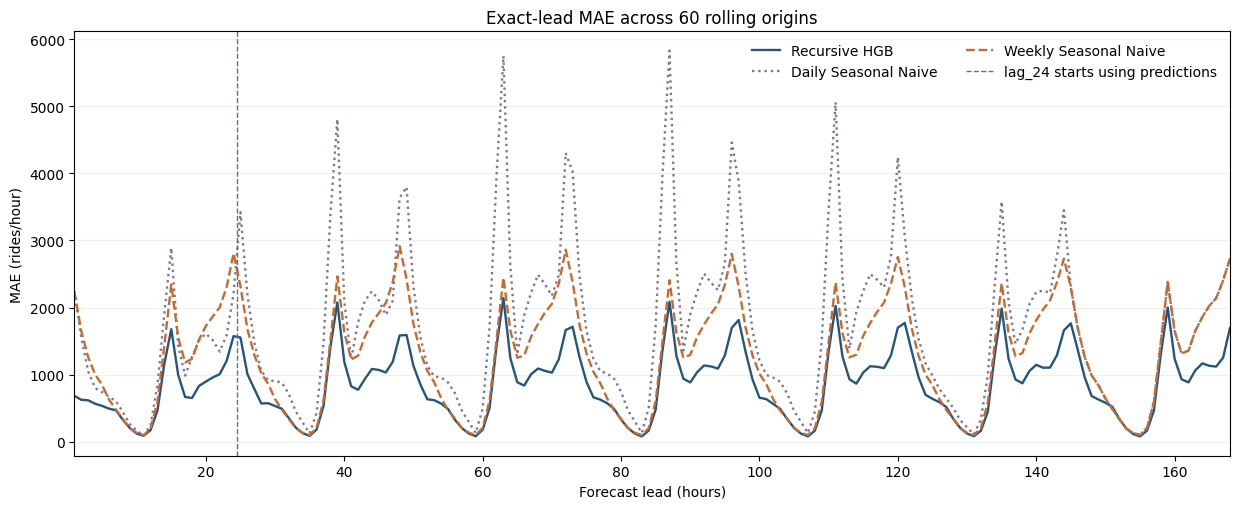

In [9]:
selected_steps = (1, 3, 6, 12, 24, 48, 72, 168)
exact_rows = []
for step in selected_steps:
    subset = panel.loc[panel["Step"] == step]
    for method in methods:
        exact_rows.append({"Step": step, "Method": method, "Pairs": len(subset),
                           **score(subset["Actual"], subset[method])})
exact_horizon_table = pd.DataFrame(exact_rows)
display(exact_horizon_table.loc[
    exact_horizon_table["Method"].eq("Recursive HGB")
].drop(columns="Method").round(1))

curve_rows = []
for step, subset in panel.groupby("Step", sort=True):
    for method in ("Recursive HGB", "Daily Seasonal Naive", "Weekly Seasonal Naive"):
        curve_rows.append({"Step": step, "Method": method,
                           "MAE": (subset["Actual"] - subset[method]).abs().mean()})
horizon_curve = pd.DataFrame(curve_rows)
fig, ax = plt.subplots(figsize=(12.5, 5.2))
for method, style in (("Recursive HGB", "-"),
                      ("Daily Seasonal Naive", ":"),
                      ("Weekly Seasonal Naive", "--")):
    series = horizon_curve.loc[horizon_curve["Method"].eq(method)]
    ax.plot(series["Step"], series["MAE"], color=COLORS[method],
            linestyle=style, linewidth=1.7, label=method)
ax.axvline(24.5, color="#64727B", linestyle="--", linewidth=1,
           label="lag_24 starts using predictions")
ax.set(xlim=(1, 168), xlabel="Forecast lead (hours)", ylabel="MAE (rides/hour)",
       title="Exact-lead MAE across 60 rolling origins")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

### Horizon buckets：跨越 24 小时边界

分段 MAE / RMSE 用指定区间内的全部预测点计算。`25–48h` 与 `1–24h` 都含每个本地钟点一次，更适合观察 `lag_24` 开始读预测值后的变化；仍需记住天气、周末及实际目标也会改变，不能仅凭误差变大就断言全由传播造成。

In [10]:
bucket_labels = ["1–6h", "7–24h", "25–48h", "49–72h", "73–168h"]
panel["Horizon Bucket"] = pd.cut(
    panel["Step"], bins=[0, 6, 24, 48, 72, 168],
    labels=bucket_labels, ordered=True,
)
bucket_rows = []
for bucket, subset in panel.groupby("Horizon Bucket", observed=True, sort=True):
    bucket_rows.append({
        "Horizon Bucket": bucket, "Pairs": len(subset),
        **score(subset["Actual"], subset["Recursive HGB"]),
    })
bucket_table = pd.DataFrame(bucket_rows)
display(bucket_table.round(1))

,Horizon Bucket,Pairs,MAE,RMSE
0,1–6h,360,587.3,830.0
1,7–24h,1080,749.2,1172.6
2,25–48h,1440,841.8,1266.4
3,49–72h,1440,871.9,1305.5
4,73–168h,5760,900.1,1336.9


### Error by Forecast Day

每个 Forecast Day 都有相同的 24 个本地钟点，因此 Day 1 到 Day 7 的 MAE 更便于观察长距离变化。表中的 matched one-step 在**相同 origin × lead 预测点**使用真实前一小时需求；`Excess vs One-Step` 是两者 MAE 之差。`Mean Error = Actual − Prediction`；正数代表平均低估，负数代表平均高估。重复 origin 使这些数是描述性回测结果，不把相邻天的差异当作独立显著性检验。

,Forecast Day,Pairs,MAE,Mean Error,Matched One-Step MAE,Excess vs One-Step
0,Day 1,1440,708.7,-69.9,360.8,347.9
1,Day 2,1440,841.8,-126.5,360.9,480.8
2,Day 3,1440,871.9,-156.5,357.0,514.9
3,Day 4,1440,897.8,-178.7,356.2,541.5
4,Day 5,1440,900.4,-187.5,354.3,546.2
5,Day 6,1440,899.3,-179.9,358.8,540.6
6,Day 7,1440,903.1,-181.7,363.2,539.9


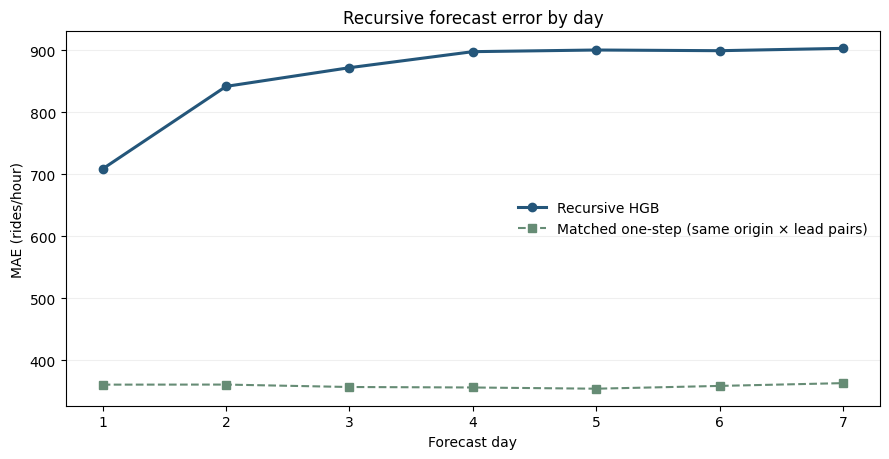

In [11]:
day_rows = []
for day, subset in panel.groupby("Forecast Day", sort=True):
    residual = subset["Actual"] - subset["Recursive HGB"]
    matched_one_step_mae = (subset["Actual"] - subset["Matched One-Step"]).abs().mean()
    day_rows.append({"Forecast Day": f"Day {day}", "Pairs": len(subset),
                     "MAE": residual.abs().mean(), "Mean Error": residual.mean(),
                     "Matched One-Step MAE": matched_one_step_mae,
                     "Excess vs One-Step": residual.abs().mean() - matched_one_step_mae})
day_table = pd.DataFrame(day_rows)
display(day_table.round(1))

fig, ax = plt.subplots(figsize=(9, 4.7))
ax.plot(range(1, 8), day_table["MAE"], marker="o", linewidth=2.2,
        color=COLORS["Recursive HGB"], label="Recursive HGB")
ax.plot(range(1, 8), day_table["Matched One-Step MAE"], marker="s",
        color=COLORS["One-Step"], linestyle="--",
        label="Matched one-step (same origin × lead pairs)")
ax.set(xticks=range(1, 8), xlabel="Forecast day", ylabel="MAE (rides/hour)",
       title="Recursive forecast error by day")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 7-Day Visualization：一条完整轨迹

选择 `2024-10-21 18:00`，展示 168 小时的真实需求、递归 HGB 与上一周同小时基线。竖线划分起点后的 Day 1–7；灰底表示周末。观察早晚峰、周末模式、逐渐变平或偏移等现象。**单条轨迹用于理解，不作为总体结论的唯一依据。**

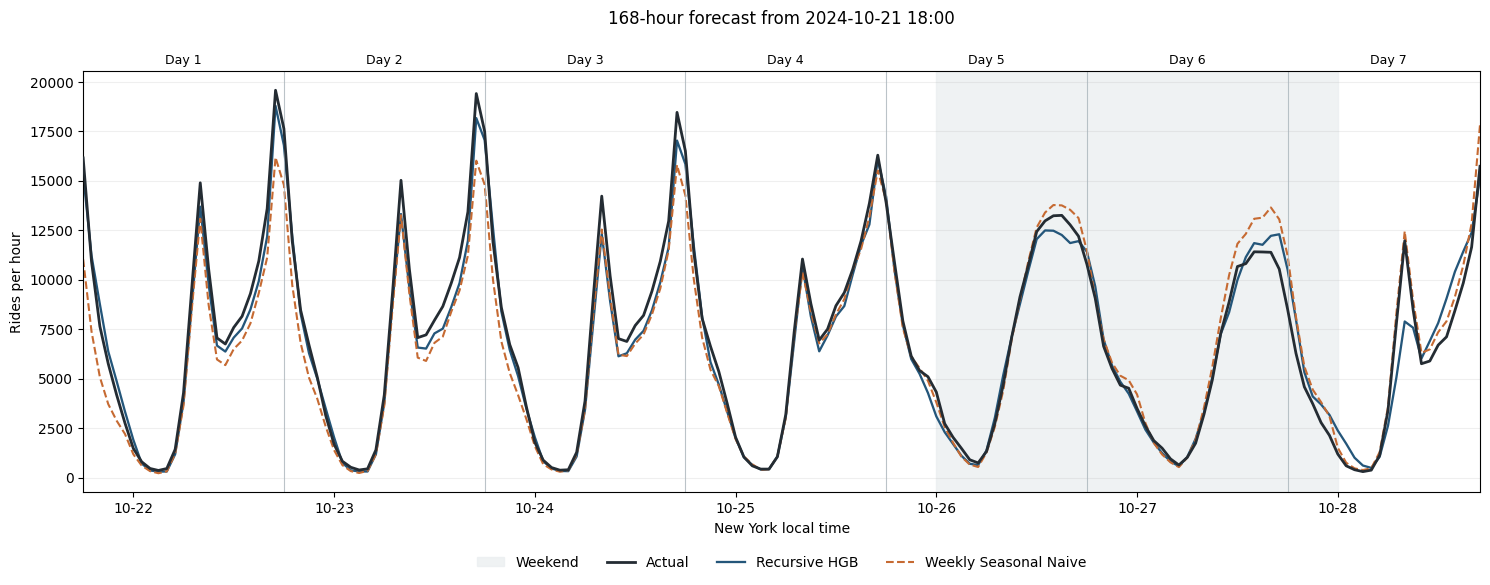

In [12]:
example = panel.loc[panel["Origin"].eq(audit_origin)].copy()
assert len(example) == 168
fig, ax = plt.subplots(figsize=(15, 6))
for left, right in ((pd.Timestamp("2024-10-26"), pd.Timestamp("2024-10-28")),):
    ax.axvspan(left, right, color="#EBEFF1", alpha=0.8, label="Weekend")
ax.plot(example["Forecast Time"], example["Actual"],
        color=COLORS["Actual"], linewidth=2, label="Actual", zorder=5)
ax.plot(example["Forecast Time"], example["Recursive HGB"],
        color=COLORS["Recursive HGB"], linewidth=1.65, label="Recursive HGB")
ax.plot(example["Forecast Time"], example["Weekly Seasonal Naive"],
        color=COLORS["Weekly Seasonal Naive"], linestyle="--", linewidth=1.5,
        label="Weekly Seasonal Naive")
for day in range(1, 8):
    start = audit_origin + pd.Timedelta(days=day - 1)
    if day > 1:
        ax.axvline(start, color="#AAB5BB", linewidth=0.8, alpha=0.8)
    midpoint = start + pd.Timedelta(hours=12)
    ax.text(midpoint, 1.01, f"Day {day}", transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=9)
ax.set(xlim=(example["Forecast Time"].min(), example["Forecast Time"].max()),
       xlabel="New York local time", ylabel="Rides per hour")
ax.set_title("168-hour forecast from 2024-10-21 18:00", pad=34)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

### Peak Hour Analysis

只看工作日：早高峰 **07–09**、晚高峰 **16–19**。按 Day 1、Day 2–3、Day 4–7 比较递归 HGB 的 MAE 和 Mean Error。长距离的高峰误差可能与递归输入、天气、节假日或日型变化共同相关，这里只做描述性判断。

In [13]:
panel["Day Group"] = pd.cut(
    panel["Forecast Day"], bins=[0, 1, 3, 7],
    labels=["Day 1", "Day 2–3", "Day 4–7"], ordered=True,
)
weekday = panel.loc[panel["Day of Week"] < 5].copy()
peak_rows = []
for period, hours in (("Morning 07–09", [7, 8, 9]),
                      ("Evening 16–19", [16, 17, 18, 19])):
    period_rows = weekday.loc[weekday["Hour"].isin(hours)]
    for group, subset in period_rows.groupby("Day Group", observed=True, sort=True):
        residual = subset["Actual"] - subset["Recursive HGB"]
        peak_rows.append({"Peak Period": period, "Forecast Days": group,
                          "Pairs": len(subset), "MAE": residual.abs().mean(),
                          "Mean Error": residual.mean()})
peak_table = pd.DataFrame(peak_rows)
display(peak_table.round(1))

,Peak Period,Forecast Days,Pairs,MAE,Mean Error
0,Morning 07–09,Day 1,129,1607.1,337.0
1,Morning 07–09,Day 2–3,264,1954.6,424.9
2,Morning 07–09,Day 4–7,507,1957.7,248.7
3,Evening 16–19,Day 1,170,1113.7,118.0
4,Evening 16–19,Day 2–3,350,1346.6,-12.4
5,Evening 16–19,Day 4–7,680,1469.7,-105.9


## Takeaways · 将三种误差放回正确语境

下一格根据上面的**实际执行输出**生成总结。它比较整段 168 小时与恰好第 168 小时的最优方法；这两个“谁最好”可能不同。有关传播的解释同时参照来源审计、Day 1/2 和桶状误差。天气仍使用 oracle 值，下一步可以独立研究 **Direct Multi-Step Forecasting**，或引入实际可获得的天气预报；本 Notebook 不实现这些扩展。

In [14]:
recursive_total = results_table.loc[results_table["Method"].eq("Recursive HGB")].iloc[0]
naive_total = results_table.loc[results_table["Method"].isin(
    ["Persistence", "Daily Seasonal Naive", "Weekly Seasonal Naive"]
)].sort_values("MAE")
best_naive = naive_total.iloc[0]
exact_168 = exact_horizon_table.loc[exact_horizon_table["Step"].eq(168)].sort_values("MAE")
best_exact_168 = exact_168.iloc[0]
best_full_168 = results_table.loc[results_table["Method"].isin(methods)].sort_values("MAE").iloc[0]
exact_hgb = exact_horizon_table.loc[
    exact_horizon_table["Method"].eq("Recursive HGB")
].set_index("Step")
day_maes = day_table.set_index("Forecast Day")["MAE"]
peak_lookup = peak_table.set_index(["Peak Period", "Forecast Days"])
day1_mae = day_maes.loc["Day 1"]
day2_mae = day_maes.loc["Day 2"]
propagation_label = (
    "上升" if day2_mae > day1_mae * 1.05 else
    "基本持平" if day2_mae >= day1_mae * 0.95 else "下降"
)
peak_lines = []
for period in ("Morning 07–09", "Evening 16–19"):
    early = peak_lookup.loc[(period, "Day 1")]
    late = peak_lookup.loc[(period, "Day 4–7")]
    peak_lines.append(
        f"{period} MAE {early['MAE']:.1f} → {late['MAE']:.1f}，"
        f"Mean Error {early['Mean Error']:+.1f} → {late['Mean Error']:+.1f}"
    )

summary = f'''
1. **One-step：**固定测试集 MAE **{one_step_mae:.2f}**、RMSE **{one_step_rmse:.2f}**、R² **{one_step_r2:.3f}**；训练 MAE **{train_mae:.2f}**。
2. **Recursive 168h 整段：**60 个 origin、10,080 个预测点，MAE **{recursive_total['MAE']:.2f}**、RMSE **{recursive_total['RMSE']:.2f}**。不同 horizon 的逐点曲线有时段起伏，整天对比更稳妥。
3. **恰好提前第 24 / 72 / 168 小时：**MAE 分别 **{exact_hgb.loc[24, 'MAE']:.2f} / {exact_hgb.loc[72, 'MAE']:.2f} / {exact_hgb.loc[168, 'MAE']:.2f}**；不是前 24/72/168 小时整体 MAE。
4. **最强 naive：**同样预测点上，**{best_naive['Method']}**（MAE **{best_naive['MAE']:.2f}**）。Recursive HGB 在 168h 整段 MAE **{'优于' if recursive_total['MAE'] < best_naive['MAE'] else '不及'}**最强 naive；整段最佳为 **{best_full_168['Method']}**。恰好第 168 小时最佳为 **{best_exact_168['Method']}**（MAE **{best_exact_168['MAE']:.2f}**）。
5. **24 小时后：**`lag_24` 从 step 25 开始读预测值；Day 1 → Day 2 MAE **{day1_mae:.1f} → {day2_mae:.1f}**，{propagation_label}。相同预测点的递归相对 one-step 额外 MAE，Day 1 → Day 7 为 **{day_table.loc[0, 'Excess vs One-Step']:.1f} → {day_table.loc[6, 'Excess vs One-Step']:.1f}**。这是观察到的差异，不能把它全部归因于传播；来源审计证明传播机制确实存在。
6. **Day 1 到 Day 7 MAE：**{', '.join(f'{day_maes.loc[f"Day {d}"]:.1f}' for d in range(1, 8))}。Mean Error 的正数表示平均低估，见上表。
7. **工作日高峰（Day 1 → Day 4–7）：**{'；'.join(peak_lines)}。比较 MAE 可判断长距离高峰是否更难，Mean Error 展示高估/低估方向。
8. **为什么 360 不能代表七天预测：**one-step 每小时使用刚观测到的真实需求；递归只能使用自身上一小时预测，rolling 和 `lag_24` 也逐步转为预测值。训练、固定测试 one-step、滚动起点 168h 分别回答不同问题。
9. **天气限制与下一步：**本实验使用测试期实际天气作为 oracle 外生输入，尚未计入天气预报误差。值得分别试验 Direct Multi-Step Forecasting 和真正可获得的天气预报输入，再评估部署效果。
'''
display(Markdown(summary))


1. **One-step：**固定测试集 MAE **360.09**、RMSE **586.06**、R² **0.977**；训练 MAE **220.80**。
2. **Recursive 168h 整段：**60 个 origin、10,080 个预测点，MAE **860.43**、RMSE **1290.69**。不同 horizon 的逐点曲线有时段起伏，整天对比更稳妥。
3. **恰好提前第 24 / 72 / 168 小时：**MAE 分别 **1574.94 / 1664.98 / 1696.67**；不是前 24/72/168 小时整体 MAE。
4. **最强 naive：**同样预测点上，**Weekly Seasonal Naive**（MAE **1269.40**）。Recursive HGB 在 168h 整段 MAE **优于**最强 naive；整段最佳为 **Recursive HGB**。恰好第 168 小时最佳为 **Recursive HGB**（MAE **1696.67**）。
5. **24 小时后：**`lag_24` 从 step 25 开始读预测值；Day 1 → Day 2 MAE **708.7 → 841.8**，上升。相同预测点的递归相对 one-step 额外 MAE，Day 1 → Day 7 为 **347.9 → 539.9**。这是观察到的差异，不能把它全部归因于传播；来源审计证明传播机制确实存在。
6. **Day 1 到 Day 7 MAE：**708.7, 841.8, 871.9, 897.8, 900.4, 899.3, 903.1。Mean Error 的正数表示平均低估，见上表。
7. **工作日高峰（Day 1 → Day 4–7）：**Morning 07–09 MAE 1607.1 → 1957.7，Mean Error +337.0 → +248.7；Evening 16–19 MAE 1113.7 → 1469.7，Mean Error +118.0 → -105.9。比较 MAE 可判断长距离高峰是否更难，Mean Error 展示高估/低估方向。
8. **为什么 360 不能代表七天预测：**one-step 每小时使用刚观测到的真实需求；递归只能使用自身上一小时预测，rolling 和 `lag_24` 也逐步转为预测值。训练、固定测试 one-step、滚动起点 168h 分别回答不同问题。
9. **天气限制与下一步：**本实验使用测试期实际天气作为 oracle 外生输入，尚未计入天气预报误差。值得分别试验 Direct Multi-Step Forecasting 和真正可获得的天气预报输入，再评估部署效果。
